<a href="https://colab.research.google.com/github/Neha-28-fluff/galaxy-vision-ai/blob/main/notebooks/day_1_dataset_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

ROOT = Path("/content/drive/MyDrive/galaxy-vision-ai")
KAGGLE = ROOT / "data/kaggle"
PROCESSED = ROOT / "data/processed"
IMAGE_DIR = ROOT / "data/kaggle/images_training_rev1"

paths = [ROOT, KAGGLE, PROCESSED]
for p in paths:
  if p.exists():
    print(f"Contents of {p}:")
    print(os.listdir(p))

Mounted at /content/drive
Contents of /content/drive/MyDrive/galaxy-vision-ai:
['notebooks', 'data']
Contents of /content/drive/MyDrive/galaxy-vision-ai/data/kaggle:
['training_solutions_rev1.csv', 'images_test_rev1.zip', 'images_training_rev1']
Contents of /content/drive/MyDrive/galaxy-vision-ai/data/processed:
['galaxy_morphology_clean_full.csv', 'images', 'train.csv', 'galaxy_morphology_clean_final.csv', 'test.csv', 'val.csv']


In [ ]:
df = pd.read_csv(KAGGLE / "training_solutions_rev1.csv")
print(f"Number of rows: {len(df)}")
df.head(5)

Number of rows: 61578


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100008,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,0.578401,0.418398,0.198455,...,0.000000,0.279952,0.138445,0.000000,0.000000,0.092886,0.0,0.0,0.0,0.325512
1,100023,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,0.165229,0.591328,0.041271,...,0.018764,0.000000,0.131378,0.459950,0.000000,0.591328,0.0,0.0,0.0,0.000000
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
3,100078,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,0.129071,0.189098,0.049466,...,0.000000,0.094549,0.000000,0.094549,0.189098,0.000000,0.0,0.0,0.0,0.000000
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


In [ ]:
df.describe()

,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
count,61578.000000,61578.000000,61578.000000,61578.000000,61578.000000,61578.000000,61578.000000,61578.000000,61578.000000,61578.000000,...,61578.000000,61578.000000,61578.000000,61578.000000,61578.000000,61578.000000,61578.000000,61578.000000,61578.000000,61578.000000
mean,550179.708337,0.432526,0.542261,0.025213,0.106408,0.435854,0.102526,0.333328,0.215629,0.220224,...,0.032780,0.091801,0.083969,0.039859,0.015411,0.094338,0.017587,0.007603,0.007006,0.073683
std,258724.130197,0.283517,0.296429,0.037967,0.212505,0.301867,0.177301,0.247675,0.285502,0.179835,...,0.098200,0.145125,0.139840,0.099657,0.052285,0.193920,0.067476,0.037678,0.037280,0.107454
min,100008.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,327874.250000,0.175812,0.280862,0.000000,0.000000,0.168490,0.000000,0.122592,0.000000,0.072656,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,551933.000000,0.416994,0.558754,0.014870,0.000000,0.394850,0.000000,0.289248,0.092987,0.183640,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,773232.000000,0.679182,0.811339,0.034325,0.085161,0.694615,0.134555,0.516800,0.330231,0.338920,...,0.000000,0.147239,0.127381,0.030621,0.000000,0.098670,0.000000,0.000000,0.000000,0.128798
max,999967.000000,1.000000,1.000000,0.935147,1.000000,1.000000,1.000000,1.000000,1.000000,0.957937,...,0.901991,0.949733,0.877393,0.996952,0.886363,1.000000,0.975913,0.957000,0.938881,0.753082


In [ ]:
required_cols = [
    "Class1.1",
    "Class1.2",
    "Class2.1",
    "Class3.1",
    "Class3.2",
    "Class4.1",
    "Class7.1",
    "Class7.2",
    "Class7.3",
    "Class8.3",
    "Class8.4",
    "Class8.6"
]

missing = [c for c in required_cols if c not in df.columns]

print("Missing Columns:", missing)

Missing Columns: []


In [ ]:
scores = pd.DataFrame(index=df.index)

# -------------------------
# ELLIPTICALS
# -------------------------

scores["Round_Elliptical"] = (
    df["Class1.1"] *
    df["Class7.1"]
)

scores["Intermediate_Elliptical"] = (
    df["Class1.1"] *
    df["Class7.2"]
)

scores["Cigar_Elliptical"] = (
    df["Class1.1"] *
    df["Class7.3"]
)

# -------------------------
# EDGE-ON DISK
# -------------------------

scores["EdgeOn_Disk"] = (
    df["Class1.2"] *
    df["Class2.1"]
)

# -------------------------
# SPIRALS
# -------------------------

scores["Barred_Spiral"] = (
    df["Class1.2"] *   # Features/Disk
    df["Class4.1"] *   # Spiral Arms
    df["Class3.1"]     # Bar Present
)

scores["Unbarred_Spiral"] = (
    df["Class1.2"] *   # Features/Disk
    df["Class4.1"] *   # Spiral Arms
    df["Class3.2"]     # No Bar
)

# -------------------------
# IRREGULAR / MERGER
# -------------------------

scores["Irregular_Merger"] = np.maximum.reduce([
    df["Class8.3"],   # Disturbed
    df["Class8.4"],   # Irregular
    df["Class8.6"]    # Merger
])

scores.head()

,Round_Elliptical,Intermediate_Elliptical,Cigar_Elliptical,EdgeOn_Disk,Barred_Spiral,Unbarred_Spiral,Irregular_Merger
0,0.077190,0.069612,0.000000,0.000000,0.009924,0.149279,0.027227
1,0.000000,0.044172,0.062758,0.020695,0.183447,0.064854,0.140353
2,0.000000,0.568058,0.018265,0.000000,0.000000,0.000000,0.000000
3,0.283313,0.197458,0.000000,0.000000,0.004939,0.005823,0.128159
4,0.461865,0.410190,0.000000,0.000000,0.000000,0.000000,0.029383


In [ ]:
df["Morphology"] = scores.idxmax(axis=1)

df["Confidence"] = scores.max(axis=1)

df[["GalaxyID", "Morphology", "Confidence"]].head()

,GalaxyID,Morphology,Confidence
0,100008,Unbarred_Spiral,0.149279
1,100023,Barred_Spiral,0.183447
2,100053,Intermediate_Elliptical,0.568058
3,100078,Round_Elliptical,0.283313
4,100090,Round_Elliptical,0.461865


In [ ]:
df["Confidence"].describe()

,Confidence
count,61578.000000
mean,0.384976
std,0.209361
min,0.004206
25%,0.212610
50%,0.352424
75%,0.529141
max,1.000000


In [ ]:
df["Confidence"].median()

0.3524236773824233

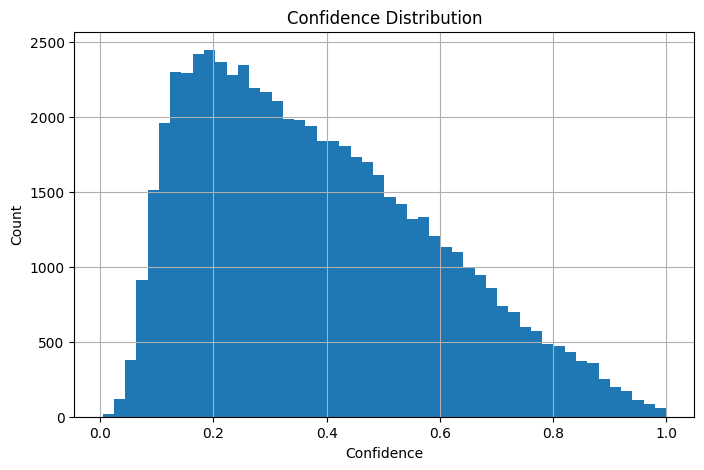

In [ ]:
plt.figure(figsize=(8,5))

df["Confidence"].hist(
    bins=50
)

plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Count")

plt.show()

In [ ]:
for t in [0.3, 0.4, 0.5, 0.6]:

    temp = df[
        df["Confidence"] >= t
    ]

    print("\n" + "="*50)
    print(f"Threshold = {t}")
    print(f"Samples = {len(temp)}")

    print(
        temp["Morphology"]
        .value_counts()
    )


Threshold = 0.3
Samples = 36221
Morphology
Round_Elliptical           9005
Intermediate_Elliptical    8779
Unbarred_Spiral            6490
EdgeOn_Disk                5638
Irregular_Merger           3541
Barred_Spiral              2159
Cigar_Elliptical            609
Name: count, dtype: int64

Threshold = 0.4
Samples = 26281
Morphology
Round_Elliptical           6734
Intermediate_Elliptical    5988
Unbarred_Spiral            4936
EdgeOn_Disk                4379
Irregular_Merger           2278
Barred_Spiral              1709
Cigar_Elliptical            257
Name: count, dtype: int64

Threshold = 0.5
Samples = 17539
Morphology
Round_Elliptical           4562
Unbarred_Spiral            3569
Intermediate_Elliptical    3519
EdgeOn_Disk                3287
Irregular_Merger           1289
Barred_Spiral              1217
Cigar_Elliptical             96
Name: count, dtype: int64

Threshold = 0.6
Samples = 10739
Morphology
Round_Elliptical           2736
Unbarred_Spiral            2392
EdgeOn_Dis

In [ ]:
CONF_THRESHOLD = 0.4

df["Morphology"] = df["Morphology"].replace(
    {
        "Cigar_Elliptical":
        "Intermediate_Elliptical"
    }
)

df_clean = df[
    df["Confidence"] >= CONF_THRESHOLD
].copy()

print("Remaining Samples:", len(df_clean))

Remaining Samples: 26281


In [ ]:
class_counts = (
    df_clean["Morphology"]
    .value_counts()
)

print(class_counts)

Morphology
Round_Elliptical           6734
Intermediate_Elliptical    6245
Unbarred_Spiral            4936
EdgeOn_Disk                4379
Irregular_Merger           2278
Barred_Spiral              1709
Name: count, dtype: int64


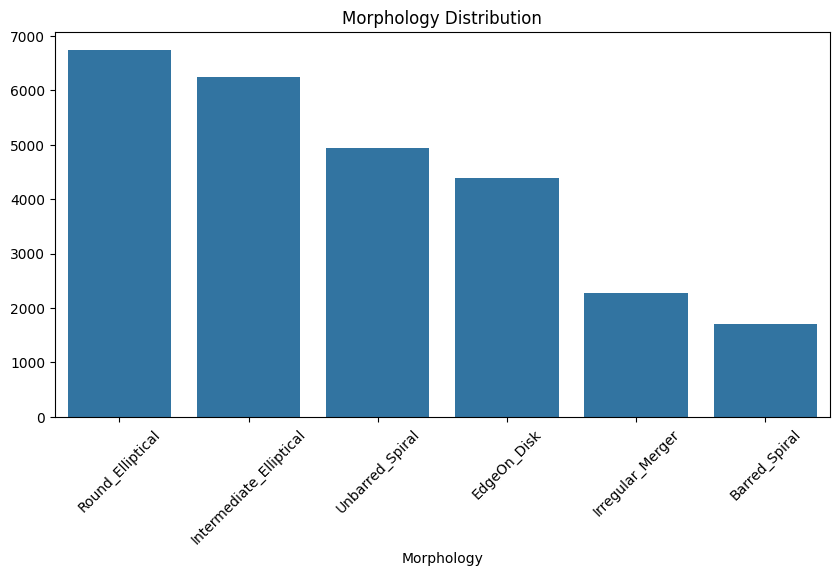

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.xticks(rotation=45)

plt.title("Morphology Distribution")

plt.show()

In [ ]:
print(
    class_counts[
        class_counts < 1000
    ]
)

Series([], Name: count, dtype: int64)


In [ ]:
from PIL import Image

def show_samples(class_name, n=9):

    sample = (
        df_clean[
            df_clean["Morphology"] == class_name
        ]
        .sort_values(
            "Confidence",
            ascending=False
        )
        .head(n)
    )

    fig, axes = plt.subplots(3,3, figsize=(8,8))

    for ax, (_, row) in zip(
        axes.flatten(),
        sample.iterrows()
    ):

        img_path = (
            IMAGE_DIR /
            f"{row['GalaxyID']}.jpg"
        )

        img = Image.open(img_path)

        ax.imshow(img)
        ax.axis("off")

    plt.suptitle(class_name)
    plt.show()

In [ ]:
# check1:
print(df_clean["GalaxyID"].head())
print(df_clean["GalaxyID"].dtype)

# check1:
import os

sample = df_clean.iloc[0]

gid = int(sample["GalaxyID"])

print(gid)

print(
    os.path.exists(
        IMAGE_DIR / f"{gid}.jpg"
    )
)

# check1:
missing = 0

for gid in df_clean["GalaxyID"]:

    path = IMAGE_DIR / f"{int(gid)}.jpg"

    if not path.exists():
        missing += 1

print("Missing:", missing)
print("Total:", len(df_clean))

#  check1:
files = os.listdir(IMAGE_DIR)

print("Total images:", len(files))

print(files[:20])

2    100053
4    100090
5    100122
6    100123
8    100134
Name: GalaxyID, dtype: int64
int64
100053
False
Missing: 0
Total: 26281
Total images: 61578
['894804.jpg', '673624.jpg', '902112.jpg', '339943.jpg', '531946.jpg', '929600.jpg', '724818.jpg', '446593.jpg', '825028.jpg', '347658.jpg', '200790.jpg', '574500.jpg', '739271.jpg', '441955.jpg', '325756.jpg', '727648.jpg', '172396.jpg', '161930.jpg', '823617.jpg', '201776.jpg']


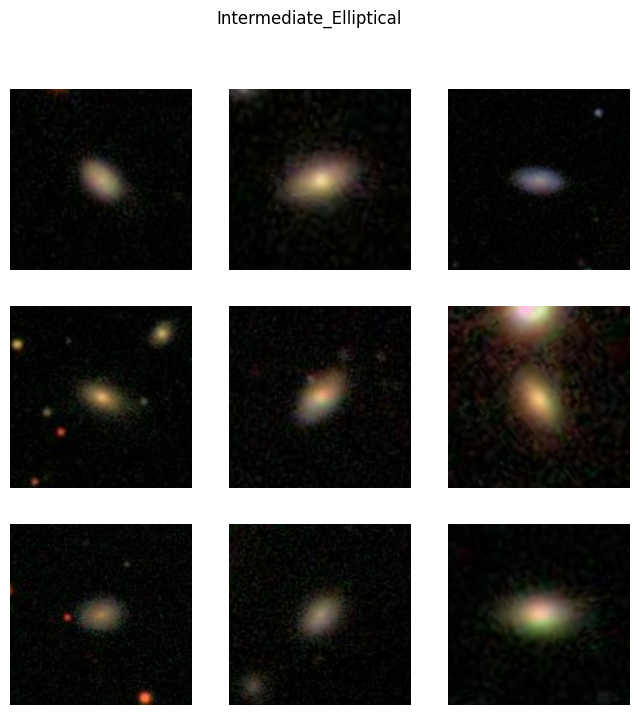

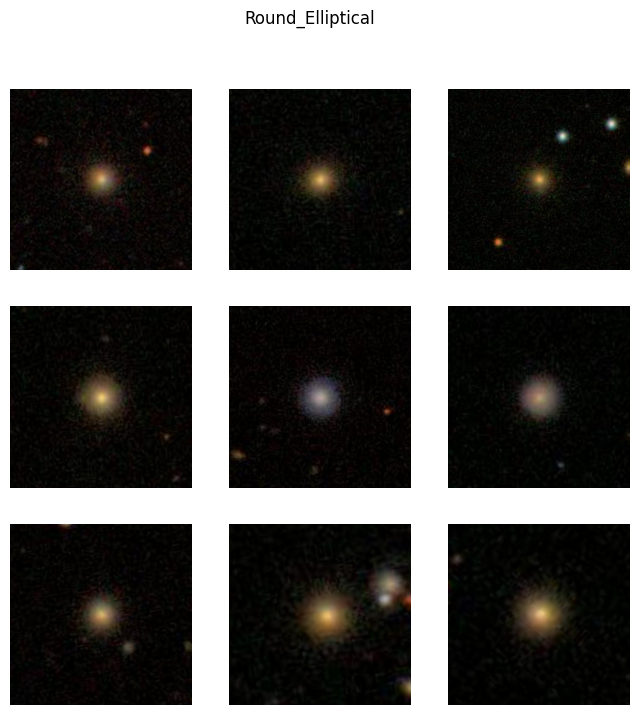

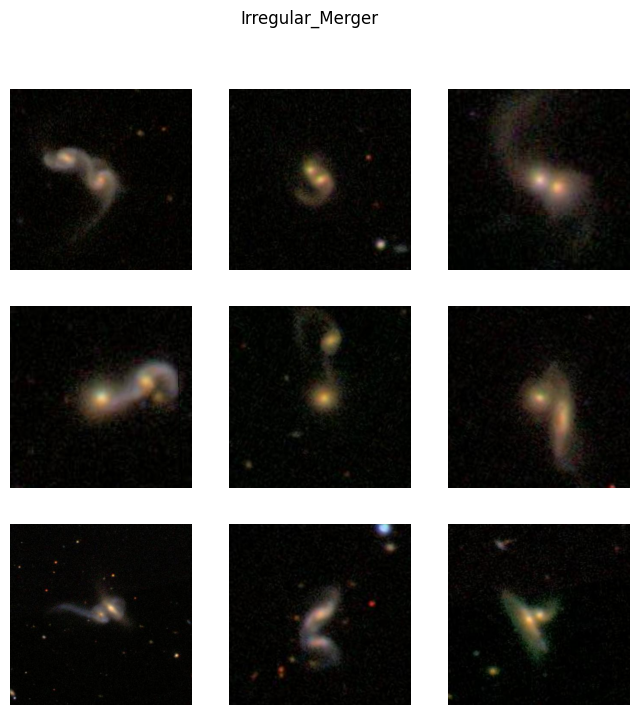

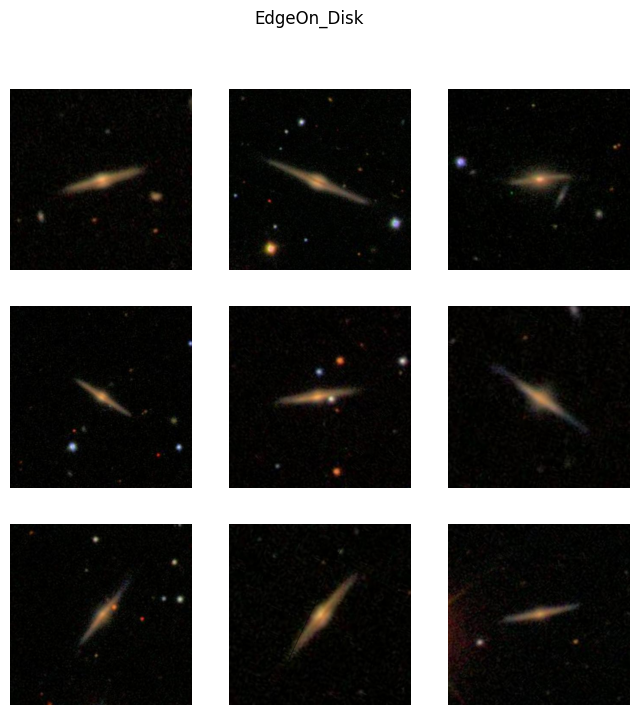

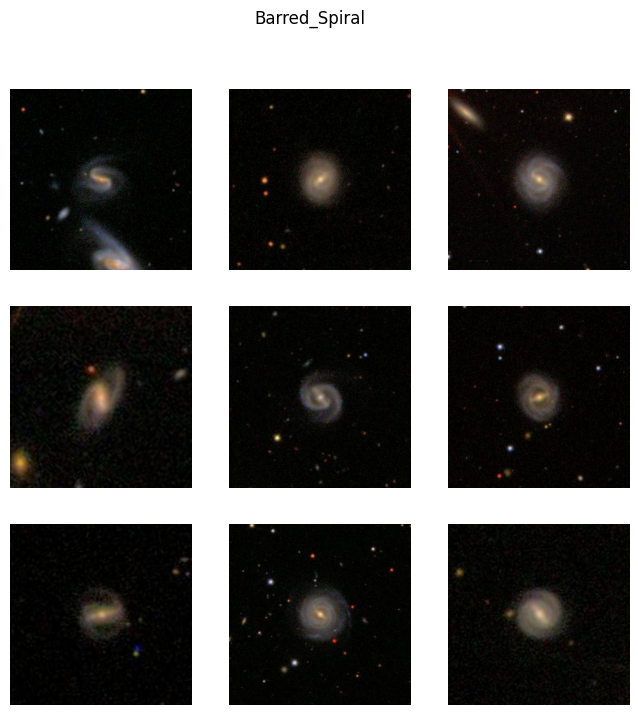

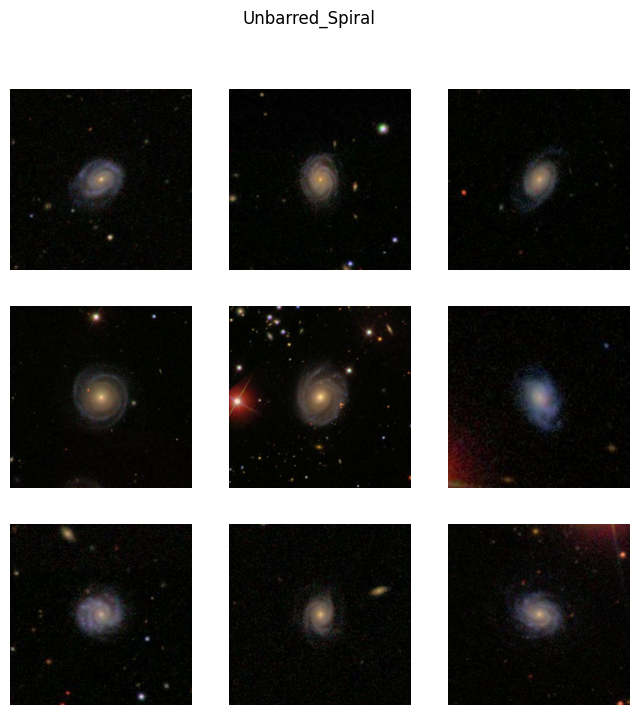

In [ ]:
for cls in df_clean["Morphology"].unique():
    show_samples(cls)

In [ ]:
for cls in sorted(df_clean["Morphology"].unique()):
    print(
        cls,
        len(df_clean[df_clean["Morphology"] == cls])
    )

Barred_Spiral 1709
EdgeOn_Disk 4379
Intermediate_Elliptical 6245
Irregular_Merger 2278
Round_Elliptical 6734
Unbarred_Spiral 4936


In [ ]:
label_map = {
    cls: idx
    for idx, cls in enumerate(
        sorted(df_clean["Morphology"].unique())
    )
}

label_map

{'Barred_Spiral': 0,
 'EdgeOn_Disk': 1,
 'Intermediate_Elliptical': 2,
 'Irregular_Merger': 3,
 'Round_Elliptical': 4,
 'Unbarred_Spiral': 5}

In [ ]:
df_clean["label"] = (
    df_clean["Morphology"]
    .map(label_map)
)

df_clean.head()

,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6,Morphology,Confidence,label
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,Intermediate_Elliptical,0.568058,2
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,Round_Elliptical,0.461865,4
5,100122,0.738832,0.238159,0.023009,0.000000,0.238159,0.000000,0.238159,0.000000,0.238159,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,Intermediate_Elliptical,0.490356,2
6,100123,0.462492,0.456033,0.081475,0.000000,0.456033,0.000000,0.456033,0.000000,0.456033,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,Irregular_Merger,0.473789,3
8,100134,0.021834,0.976952,0.001214,0.021751,0.955201,0.313077,0.642124,0.546491,0.408711,...,0.187194,0.0,0.0,0.054649,0.081974,0.081974,0.327894,Irregular_Merger,0.450225,3


In [ ]:
final_df = df_clean[
    ["GalaxyID", "Morphology", "label", "Confidence"]
].copy()

final_df.to_csv(
    PROCESSED / "galaxy_morphology_clean_final.csv",
    index=False
)

In [ ]:
from sklearn.model_selection import train_test_split

train_val, test = train_test_split(
    final_df,
    test_size=0.20,
    stratify=df_clean["Morphology"],
    random_state=42
)

train, val = train_test_split(
    train_val,
    test_size=0.125,
    stratify=train_val["Morphology"],
    random_state=42
)

print("Train:", len(train))
print("Val:", len(val))
print("Test:", len(test))

Train: 18396
Val: 2628
Test: 5257


In [ ]:
print(train["Morphology"].value_counts(normalize=True))
print()

print(val["Morphology"].value_counts(normalize=True))
print()

print(test["Morphology"].value_counts(normalize=True))

Morphology
Round_Elliptical           0.256251
Intermediate_Elliptical    0.237660
Unbarred_Spiral            0.187813
EdgeOn_Disk                0.166612
Irregular_Merger           0.086649
Barred_Spiral              0.065014
Name: proportion, dtype: float64

Morphology
Round_Elliptical           0.256088
Intermediate_Elliptical    0.237443
Unbarred_Spiral            0.187976
EdgeOn_Disk                0.166667
Irregular_Merger           0.086758
Barred_Spiral              0.065068
Name: proportion, dtype: float64

Morphology
Round_Elliptical           0.256230
Intermediate_Elliptical    0.237588
Unbarred_Spiral            0.187750
EdgeOn_Disk                0.166635
Irregular_Merger           0.086741
Barred_Spiral              0.065056
Name: proportion, dtype: float64


In [ ]:
train.to_csv(
    PROCESSED / "train.csv",
    index=False
)

val.to_csv(
    PROCESSED / "val.csv",
    index=False
)

test.to_csv(
    PROCESSED / "test.csv",
    index=False
)

final_df.to_csv(
    PROCESSED / "galaxy_morphology_clean_final.csv",
    index=False
)

In [ ]:
train_check = pd.read_csv(
    PROCESSED / "train.csv"
)

train_check.head()

,GalaxyID,Morphology,label,Confidence
0,225927,EdgeOn_Disk,1,0.626851
1,607435,Unbarred_Spiral,5,0.469441
2,407594,Intermediate_Elliptical,2,0.726658
3,683796,Irregular_Merger,3,0.546769
4,113655,Unbarred_Spiral,5,0.733071


In [ ]:
PROCESSED_IMAGES = PROCESSED / "images"

PROCESSED_IMAGES.mkdir(
    parents=True,
    exist_ok=True
)

In [28]:
import shutil

copied = 0

for galaxy_id in final_df["GalaxyID"]:

    src = IMAGE_DIR / f"{int(galaxy_id)}.jpg"
    dst = PROCESSED_IMAGES / f"{int(galaxy_id)}.jpg"

    if src.exists():
        shutil.copy2(src, dst)
        copied += 1

print("Copied:", copied)

Copied: 26281
